In [24]:
import numpy as np
import pandas as pd
import graphviz
import lingam
from lingam.utils import make_dot

print([np.__version__, pd.__version__, graphviz.__version__, lingam.__version__])

np.set_printoptions(precision=3, suppress=True)
np.random.seed(100)

csv='LiNGAM_latest3'
csv='nonlinear_LiNGAM_latest3a'
csv='nonlinear_LiNGAM_latest3b'
csv='nonlinear_LiNGAM_latest3c'

def Causal_discovery_test( csv ):
    csv_data = pd.read_csv('../Causal_discovery-Experiment-main/Causal_discovery-Experiment-main/Causal_Search_Experiment/'+csv+'.csv')
    print(csv_data)
    
    X = pd.DataFrame(csv_data, columns=["x1", "x2", "x3", "x4", "x5","f1","f2"])
    model = lingam.ICALiNGAM()
    model.fit(X)
    dot1 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5','f1','f2'])
    
    dot1
    dot1.graph_attr.update({
        'label': 'ICALiNGAM',
        'labelloc': 't', 
        'fontsize': '20' 
    })
    dot1.render('ICALiNGAM', format='png')
    
    X=X[['x1','x2','x3','x4','x5']]
    X.head()
    model = lingam.ICALiNGAM()
    model.fit(X)
    dot2 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5'])
    
    dot2.graph_attr.update({
        'label': 'ICALiNGAM(f1,f2 delete)', 
        'labelloc': 't',                  
        'fontsize': '20'                  
    })
    dot2.render('ICALiNGAM(f1,f2 delete)', format='png')
    dot2

    
    model = lingam.RCD()
    model.fit(X)
    dot3 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5'])
    
    dot3.graph_attr.update({
        'label': 'RCD(f1,f2 delete)',  
        'labelloc': 't',                  
        'fontsize': '20'                 
    })
    dot3.render('RCD(f1,f2 delete)', format='png')    


    model = lingam.BottomUpParceLiNGAM()
    model.fit(X)
    dot4 = make_dot(model.adjacency_matrix_, labels=['x1','x2','x3','x4','x5'])
    
    
    dot2.graph_attr.update({
        'label': 'BottomUpParceLiNGAM(f1,f2 delete)',  
        'labelloc': 't',                  
        'fontsize': '20'                  
    })
    dot2.render('BottomUpParceLiNGAM(f1,f2 delete)', format='png')


    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 4, figsize=(12*2*2, 6*2*2))
    
    ax[0].imshow( plt.imread('ICALiNGAM.png'))
    ax[1].imshow( plt.imread('ICALiNGAM(f1,f2 delete).png'))
    ax[2].imshow( plt.imread('RCD(f1,f2 delete).png'))
    ax[3].imshow( plt.imread('BottomUpParceLiNGAM(f1,f2 delete).png'))
    fig.tight_layout() 
    plt.savefig('Causal_discovery'+csv+'.png')
    plt.tight_layout()
    plt.show()    

['1.26.4', '2.2.3', '0.20.3', '1.9.1']


            x1        x2        x3        x4        x5        f1        f2
0     0.696469  1.202258  1.123601  0.623284  1.304165  0.663142  0.086478
1     0.286139  1.295332  1.257757  1.452096 -0.271077  0.839786  0.584164
2     0.226851  1.286709  1.665769  0.684246  0.697509  0.823654  0.472752
3     0.551315  0.701835  1.488863  0.903633  0.653487  0.367612  0.702623
4     0.719469 -0.076194  0.843877  1.165409  0.628765  0.175591  0.461606
...        ...       ...       ...       ...       ...       ...       ...
9995  0.354765  1.635611  1.736813 -0.014618  1.414499  0.797820  0.153824
9996  0.585060  0.689019  1.544292  1.135218 -0.196607  0.127115  0.980067
9997  0.985145  0.308883  1.010549  0.023759  1.706193  0.445073  0.121931
9998  0.220662  0.298138  1.769249  1.275190 -0.130321  0.277073  0.847017
9999  0.613297  0.249368  0.807696  1.068973  0.386795  0.279937  0.509738

[10000 rows x 7 columns]


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: U

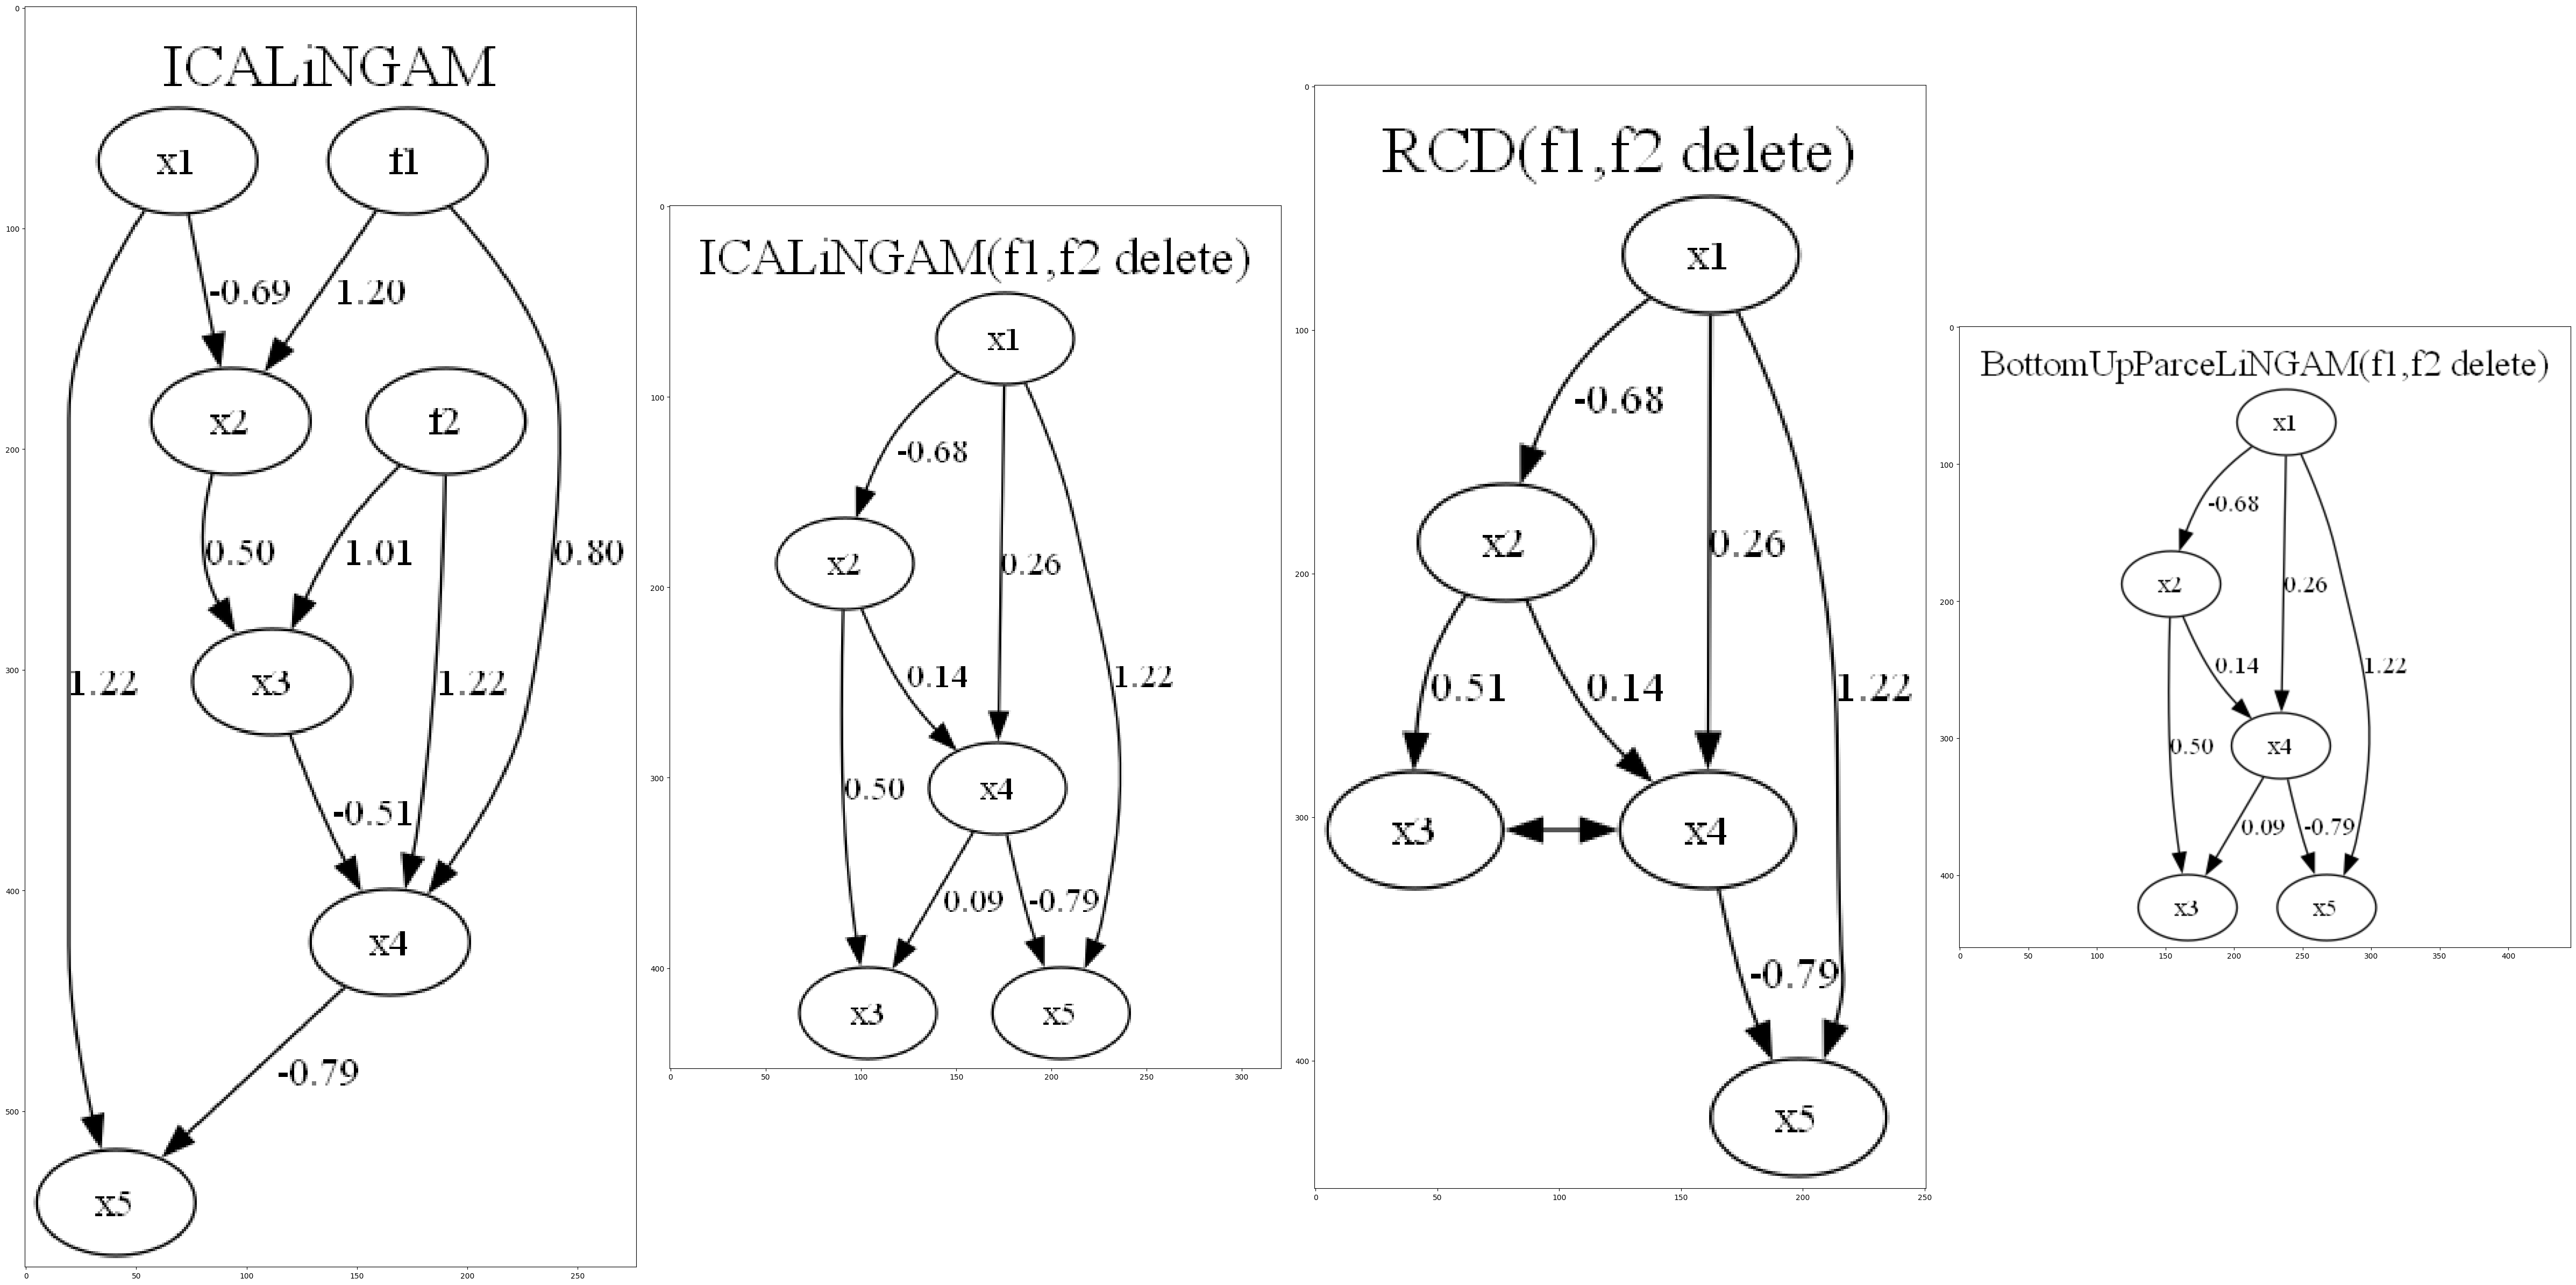

            x1        x2        x3        x4        x5        f1        f2
0     0.589408  0.682773  0.360227  0.194517  1.249551  0.163142 -0.413522
1    -0.641582  0.338293  0.677526 -0.047203  0.930541  0.339786  0.084164
2    -0.819446  0.112778  0.926911  0.077927  0.839725  0.323654 -0.027248
3     0.153944  0.651064  0.901301  0.149834  0.731999 -0.132388  0.202623
4     0.658407  0.039565  0.894413  0.186243  1.040785 -0.324409 -0.038394
...        ...       ...       ...       ...       ...       ...       ...
9995 -0.435705  0.900112  0.646317  0.198154  0.252147  0.297820 -0.346176
9996  0.255181  1.067293  1.376605 -0.254348  0.629316 -0.372885  0.480067
9997  1.455435 -1.014787 -0.240862  0.037794  3.423924 -0.054927 -0.378069
9998 -0.838014 -0.311838  0.606412  0.061188  1.585040 -0.222927  0.347017
9999  0.339891  0.319997  0.084617  0.014331  0.706993 -0.220063  0.009738

[10000 rows x 7 columns]


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: U

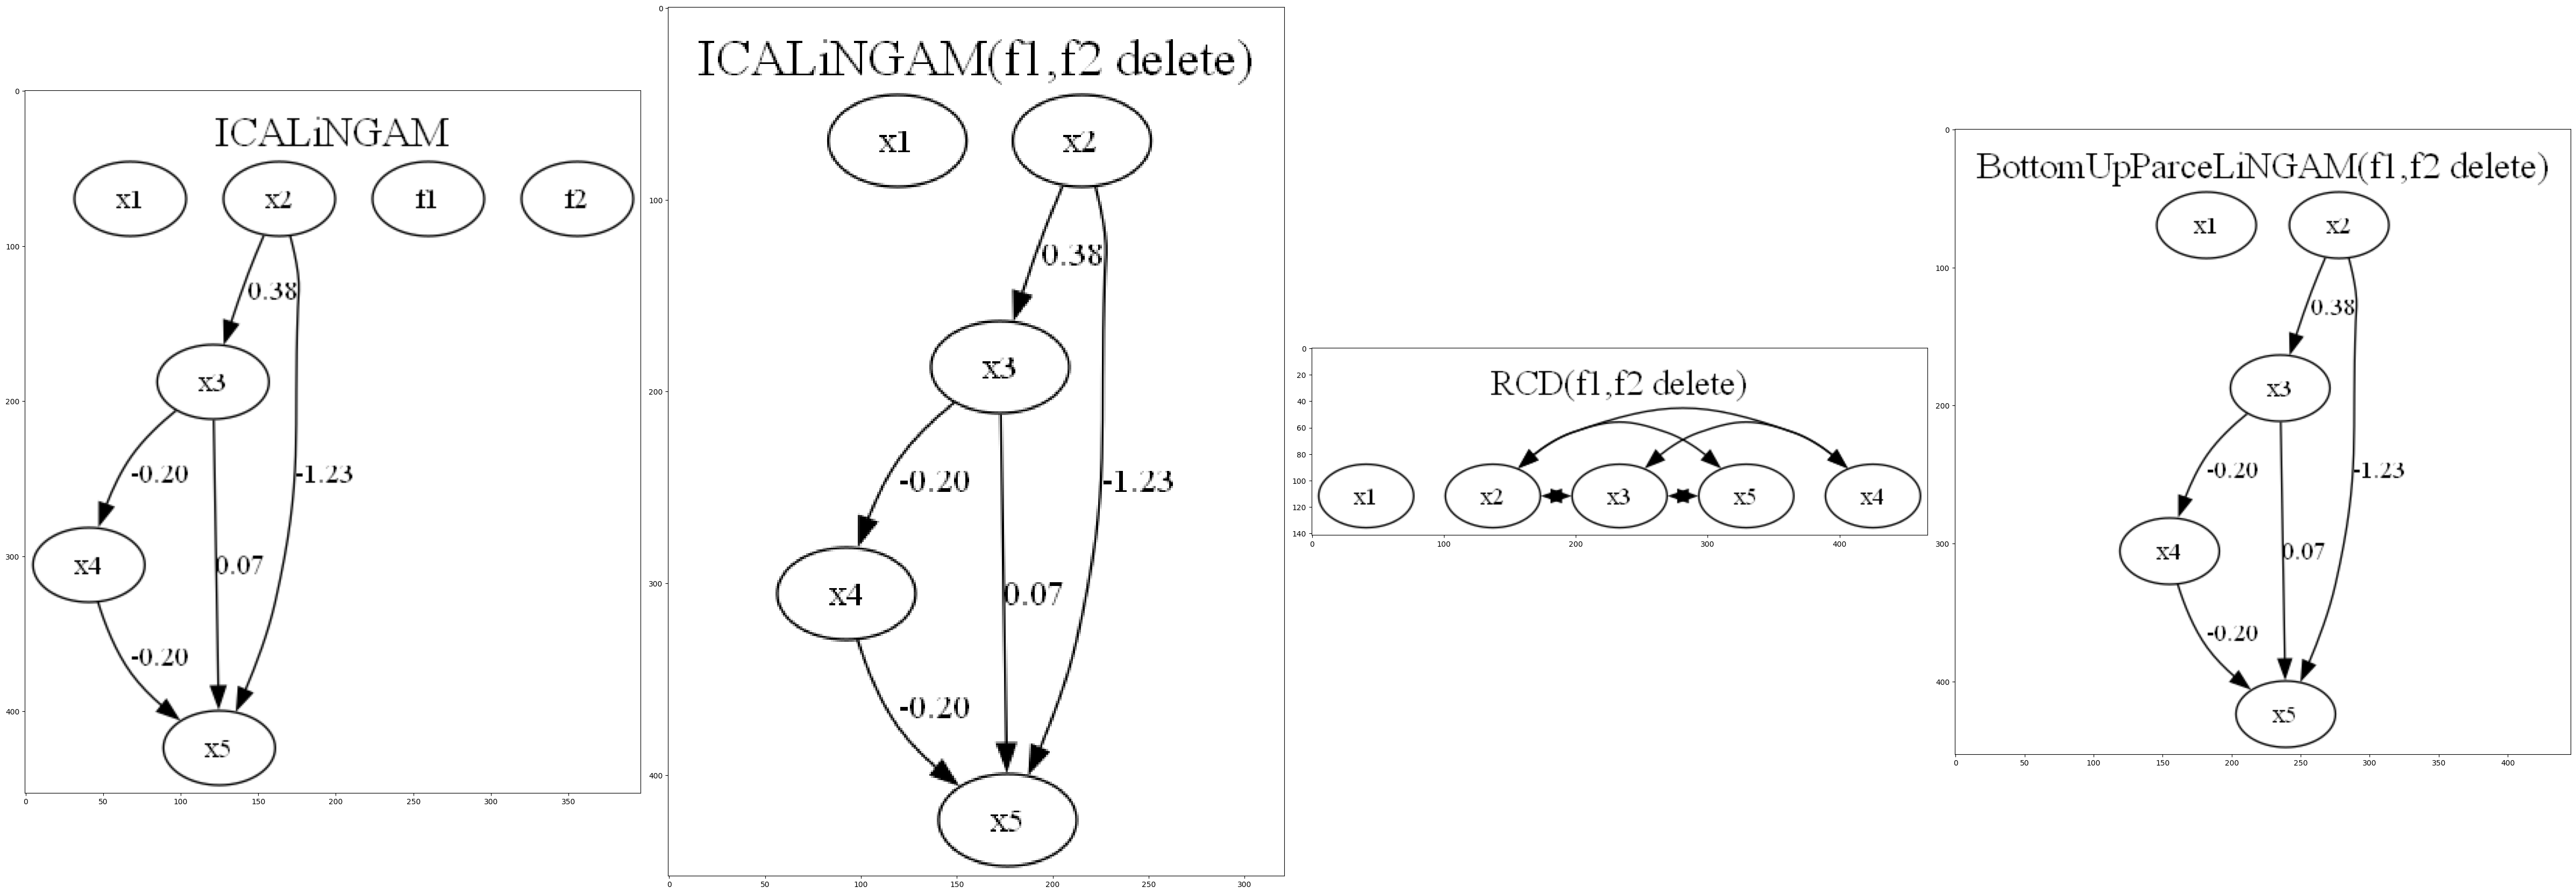

            x1        x2        x3        x4        x5        f1        f2
0     0.589408  0.268574  0.250273  0.280758  0.841256 -0.251244 -0.176665
1    -0.641582 -0.549896 -0.222551 -0.382573  0.854104 -0.336933 -0.269753
2    -0.819446  0.863022  2.001715  0.313147  0.078037  0.283643  0.293779
3     0.153944  0.976790  1.644942  0.101834  0.998774  0.308523  0.124420
4     0.658407 -0.104077  1.372572  0.741293  0.696793  0.125628  0.475410
...        ...       ...       ...       ...       ...       ...       ...
9995 -0.435705  0.143414  0.167447  0.028679  0.612575  0.126770  0.004845
9996  0.255181  0.939409  1.069891 -0.002438  0.834896  0.070124 -0.150135
9997  1.455435 -0.355820 -0.473849  0.921808  3.674172  0.461136 -0.435443
9998 -0.838014 -0.927924  0.931164  0.000266  0.673535 -0.406212  0.049836
9999  0.339891  0.338025  0.428764  0.093270  0.738239  0.248378 -0.365533

[10000 rows x 7 columns]


C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(
C:\Users\yamato\Desktop\work\python_wrk\lingam_test_note\Lib\site-packages\scipy\stats\_morestats.py:1882: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


In [ ]:
csv1='LiNGAM_latest3'
csv2='nonlinear_LiNGAM_latest3a'
csv3='nonlinear_LiNGAM_latest3b'
csv4='nonlinear_LiNGAM_latest3c'

Causal_discovery_test( csv1 )
Causal_discovery_test( csv2 )
Causal_discovery_test( csv3 )
Causal_discovery_test( csv4 )
Causal_discovery_test( csv5 )
Causal_discovery_test( csv6 )


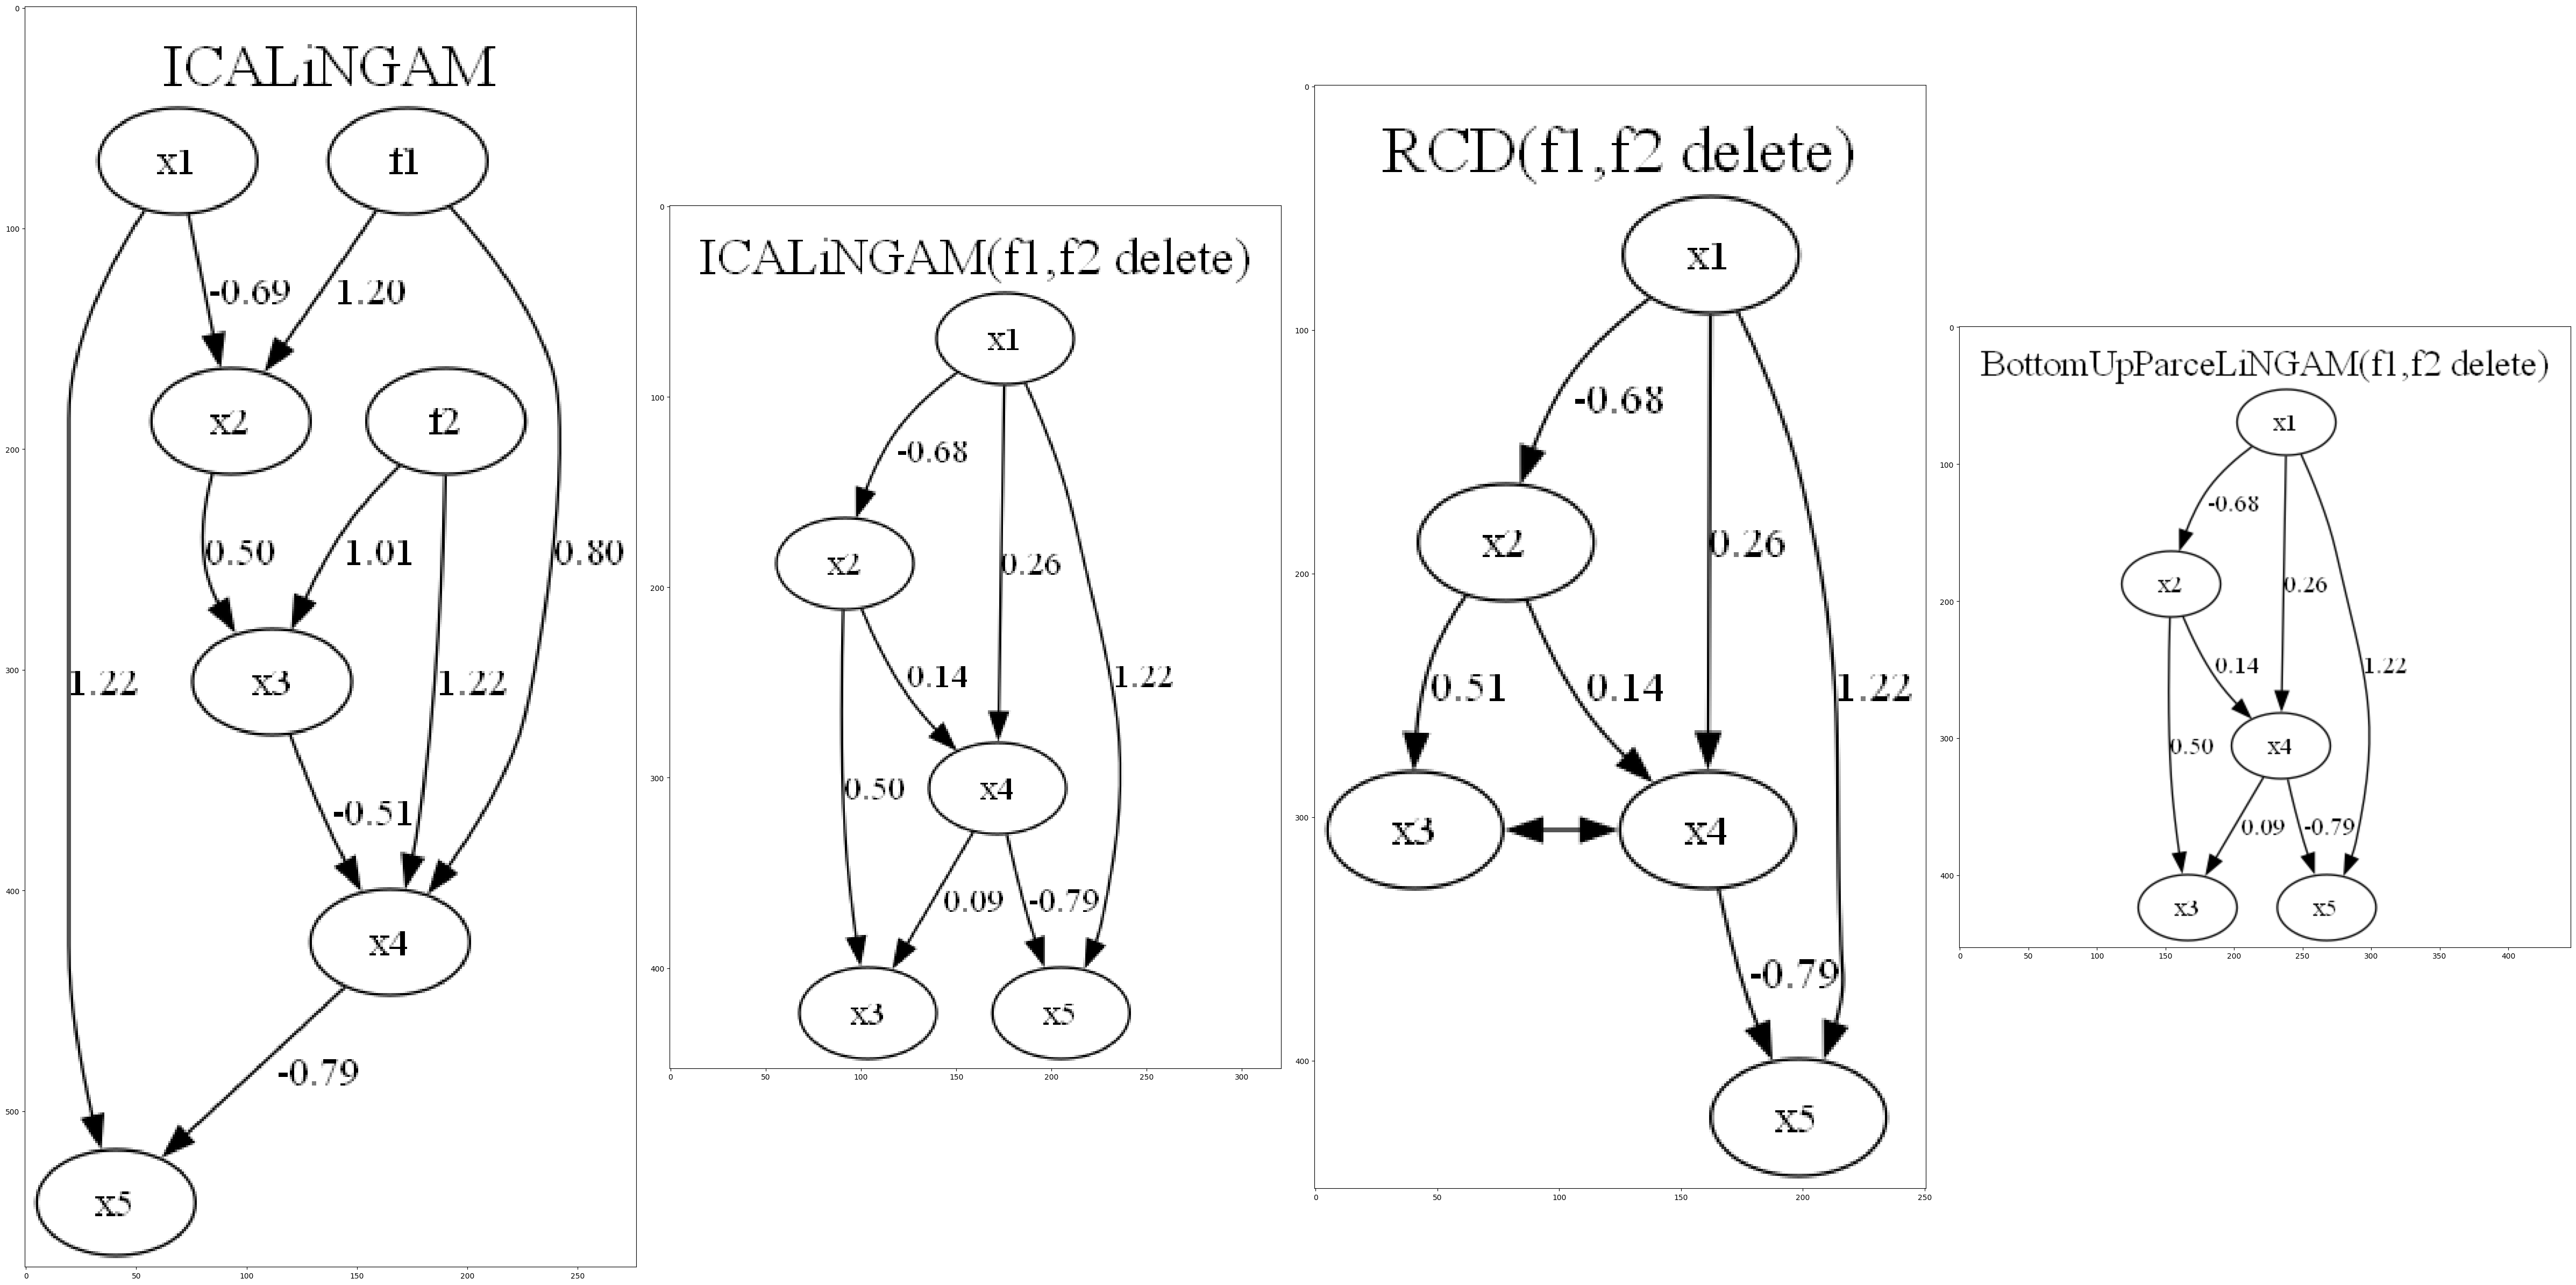